## Figure A6 - Tahoe LFC Lasso Boxplot (No-Tahoe LPM Embeddings)

All models are evaluated on the compound subset covered by `no_tahoe_embeddings/tahoe_sci_op3_no_tahoe_embeddings.pkl`.


In [1]:
import pandas as pd
import seaborn as sns
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl


## Settings


In [2]:
lasso_or_knn = "lasso" # knn, lasso


## Load scores and plotting metadata


In [3]:
repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "results" / "scores" / "no_tahoe_embeddings" / "tahoe_lfc_restricted.csv").exists()
)
df = pd.read_csv(repo_root / "results" / "scores" / "no_tahoe_embeddings" / "tahoe_lfc_restricted.csv", index_col=0)


In [4]:
with open(repo_root / "results" / "metadata" / "fig_index.json", "r") as f:
    fig_index = json.load(f)

method_map = {
    k.replace("HEAD_TYPE", lasso_or_knn): v
    for k, v in fig_index["tahoe_lfc"].items()
}
method_map.update({
    f"{lasso_or_knn}_baseline_LPM_emb": ["LPM", "Response Embedding"],
    # f"{lasso_or_knn}_baseline_ECFP:2_pkl": ["ECFP:2 (pkl)", "Molecule Structure"],
})
model_type_palette = fig_index['drugs_model_type_palette']
model_type_palette["Response Embedding"] = "#8CD17DFF"
hue_order = fig_index['drugs_hue_order']
hue_order = [*hue_order, "Response Embedding"]
mpl.rcParams.update(fig_index["mpl_params"])
# mpl.rcParams.update({"legend.loc": "upper right"})


## Aggregated figure


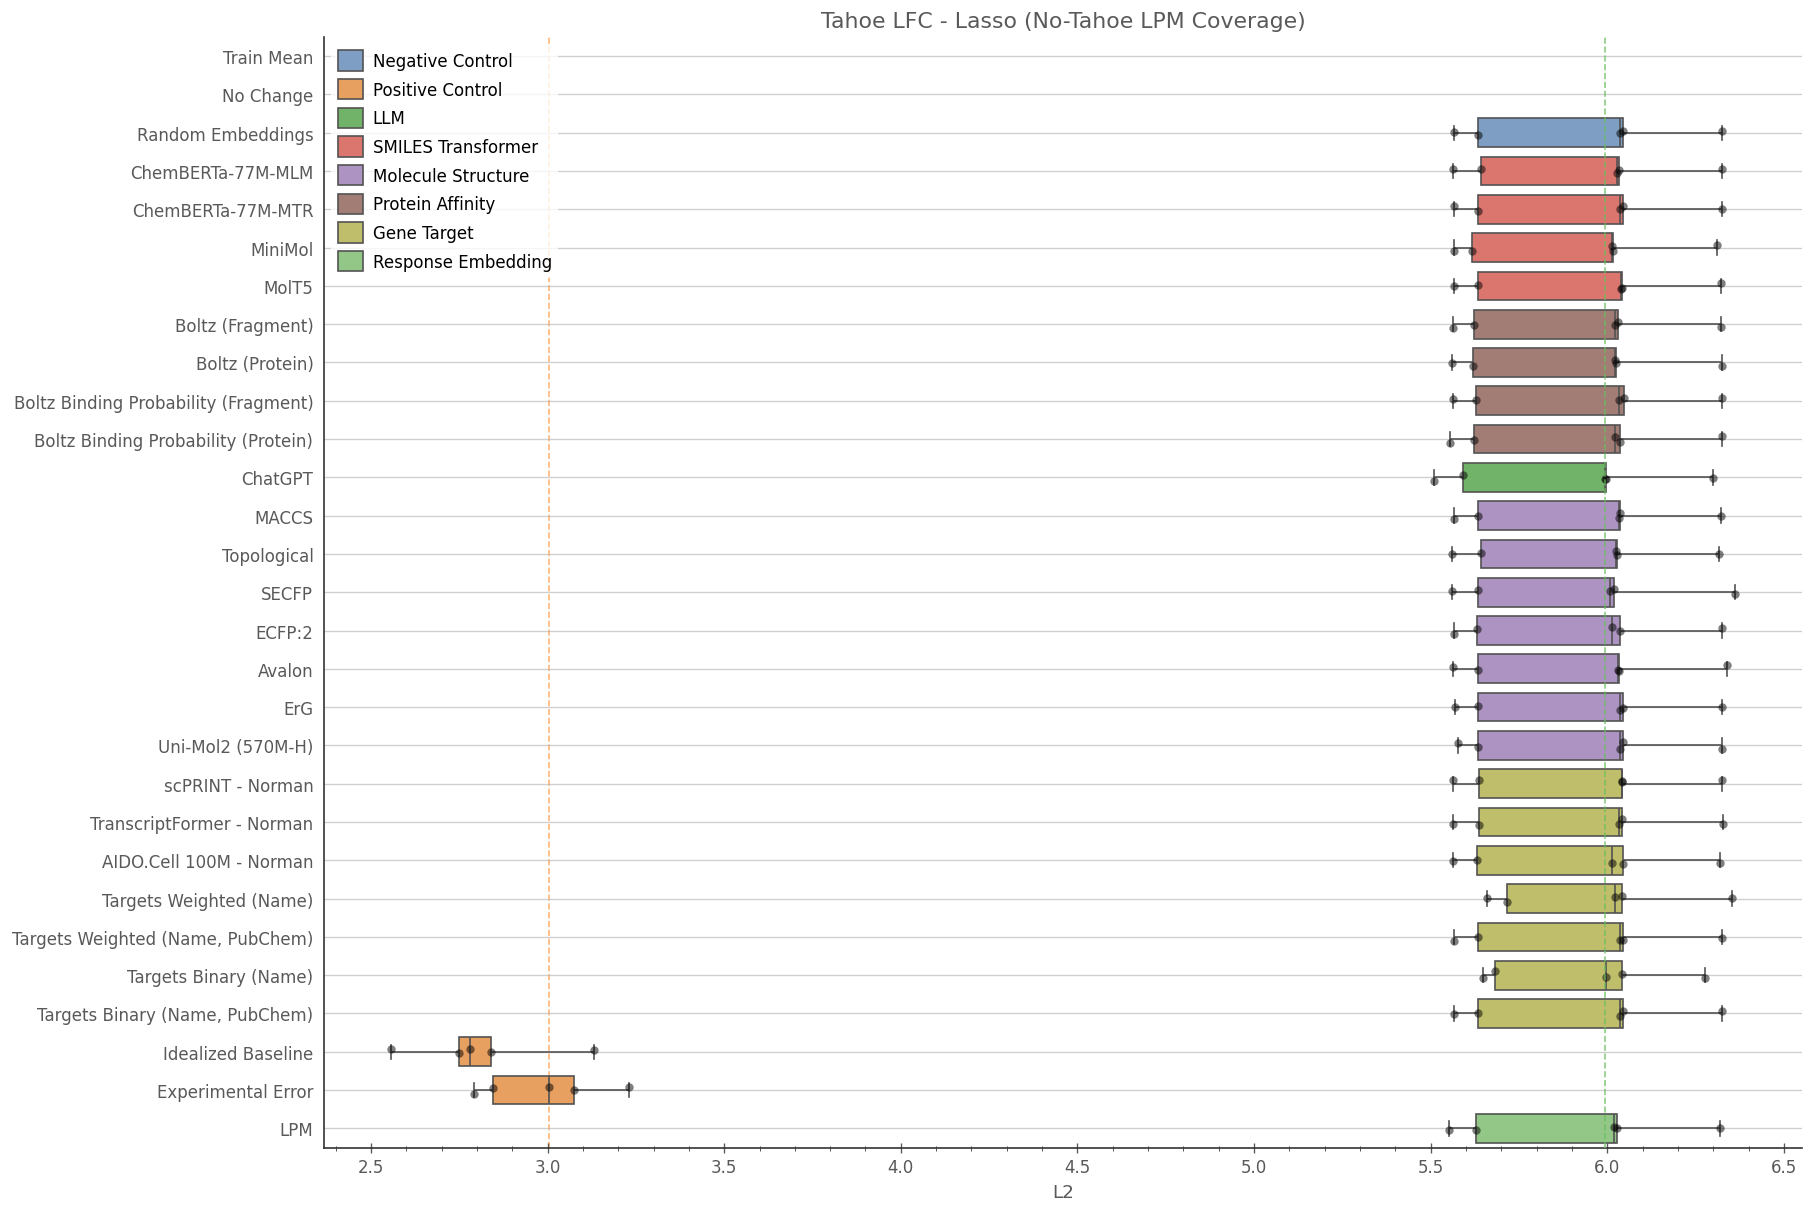

In [5]:
fig, ax = plt.subplots(figsize=(15, 10), constrained_layout=True)

df_subset = df[df["name"].isin(method_map)].copy()
df_subset["fold"] = df_subset["fold"].apply(lambda x: x if "." not in str(x) else x.split(".")[1])
df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

# Aggregate
df_subset = df_subset.groupby(["fold", "name", "Model type"])["L2"].mean().reset_index()

present_hues = [
    h for h in hue_order
    if h in df_subset["Model type"].unique()
]

# Boxplot
g = sns.boxplot(
    data=df_subset,
    y="name",
    order=[name for name, _ in method_map.values()],
    hue="Model type",
    hue_order=present_hues,
    x="L2",
    ax=ax,
    whis=(0, 100),
    width=0.75,
    palette=model_type_palette,
)

# Overlay stripplot
sns.stripplot(
    data=df_subset,
    y="name",
    order=[name for name, _ in method_map.values()],
    color="black",
    alpha=0.5,
    s=5,
    x="L2",
    ax=ax,
)

# Decorate
g.grid(axis="y")
g.set(ylabel=None, title="Tahoe LFC - Lasso (No-Tahoe LPM Coverage)")
g.set_xlabel('L2')
g.legend(title=None)

# Get the best performing model
best_mask = (
    (df_subset["Model type"] != "Positive Control") &
    (df_subset["Model type"] != "Fusion")
)
best_group = (
    df_subset.loc[best_mask]
    .groupby("name")["L2"]
    .median()
)
best_name = best_group.idxmin()
best_level = best_group.loc[best_name]
best_model_type = (
    df_subset.loc[df_subset["name"] == best_name, "Model type"]
    .iloc[0]
)

# Draw vertical lines
g.axvline(
    df_subset[df_subset["name"] == "Train Mean"]["L2"].median(),
    color=model_type_palette["Negative Control"],
    linestyle="--",
    linewidth=1,
    zorder=99,
    alpha=0.75,
)
g.axvline(
    df_subset[
        df_subset["name"] == f"Experimental Error"
    ]["L2"].median(),
    color=model_type_palette["Positive Control"],
    linestyle="--",
    linewidth=1,
    zorder=-99,
    alpha=0.75,
)
g.axvline(
    best_level,
    color=model_type_palette[best_model_type],
    linestyle="--",
    linewidth=1,
    zorder=99,
    alpha=0.75,
)
plt.savefig("fig_A6_no_tahoe_embeddings.pdf")
plt.savefig("fig_A6_no_tahoe_embeddings.png", dpi=200)
